In [2]:
import pandas as pd
df_final = pd.read_csv('Data_for_modelling.csv', index_col=0)

In [3]:
df_final

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Total_Acquisition_Cost,...,Language_Hindi,Language_Tamil,Customer_Segment_Premium Shoppers,Customer_Segment_Tier 2 City Customers,Customer_Segment_Working Women,Customer_Segment_Youth,CTR,Conversion_Rate,CPC,CPL
0,21.000000,57804.0,6156.000000,3616.0,2355.000000,1867515.0,162.31857,3.885455,20.980000,382260.232841,...,1,0,0,0,0,0,0.106498,0.382554,62.095554,105.713560
1,18.000000,91801.0,3321.000000,1971.0,1357.000000,1046247.0,180.83000,3.263673,7.240000,245386.310000,...,1,0,0,0,0,0,0.036176,0.408612,73.889283,124.498381
2,23.000000,15536.0,2182.000000,952.0,755.000000,197055.0,90.60000,1.880795,25.030000,68403.000000,...,0,0,0,0,0,0,0.140448,0.346013,31.348762,71.851890
3,10.000000,96871.0,3743.000000,2060.0,1258.000000,518296.0,228.60000,0.802275,7.290000,287578.800000,...,1,0,0,1,0,0,0.038639,0.336094,76.831098,139.601359
4,21.000000,82267.0,5458.378102,1873.0,1386.000000,633402.0,210.17000,1.174430,9.906739,291295.620000,...,0,1,0,0,0,1,0.066350,0.253922,53.366699,155.523555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118950,7.000000,78207.0,3086.000000,883.0,620.000000,199020.0,362.11000,-0.113529,5.870000,224508.200000,...,0,0,0,0,0,0,0.039459,0.200907,72.750551,254.256169
118951,14.000000,38933.0,2683.000000,1307.0,931.000000,641459.0,298.63000,1.307203,13.857298,278024.530000,...,1,0,1,0,0,0,0.068913,0.347000,103.624498,212.719608
118952,15.000000,25929.0,1388.000000,808.0,567.000000,408240.0,258.43000,1.786054,10.660000,146529.810000,...,1,0,0,0,1,0,0.053531,0.408501,105.569027,181.348773
118953,20.000000,54886.0,1578.000000,634.0,296.082674,136514.0,436.24000,0.056912,4.660000,129163.105647,...,0,0,0,0,1,0,0.028751,0.187632,81.852411,203.727293


In [4]:
from sklearn.model_selection import train_test_split

# Define target columns that must be dropped from features to prevent leakage/cheating
leakage_cols = ['Revenue', 'Net_Profit', 'Profit_Loss',]

# 1. Prepare Data for REGRESSION MODEL (Target: Revenue)
X_reg = df_final.drop(columns=leakage_cols)
y_reg = df_final['Revenue']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 2. Prepare Data for CLASSIFICATION MODEL (Target: Profit_Loss)
# For classification, 'Revenue' can be kept as a feature since it's an input to profit calculation
X_clf = df_final.drop(columns=['Net_Profit', 'ROI', 'Profit_Loss'])
y_clf = df_final['Profit_Loss']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Regression Data Split Summary | Features: {X_train_reg.shape[1]} | Train Rows: {X_train_reg.shape[0]} | Test Rows: {X_test_reg.shape[0]}")
print(f"Classification Data Split Summary | Features: {X_train_clf.shape[1]} | Train Rows: {X_train_clf.shape[0]} | Test Rows: {X_test_clf.shape[0]}")

Regression Data Split Summary | Features: 36 | Train Rows: 95164 | Test Rows: 23791
Classification Data Split Summary | Features: 36 | Train Rows: 95164 | Test Rows: 23791


In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Initialize the regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# Dictionary to store performance metrics
reg_results = []

print("Training regression models...")
for name, model in reg_models.items():
    # Fit the model
    model.fit(X_train_reg, y_train_reg)
    
    # Predict on test data
    y_pred = model.predict(X_test_reg)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)
    
    # Save results
    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })
    print(f"✓ {name} trained successfully.")

# Display results as a clean DataFrame
df_reg_results = pd.DataFrame(reg_results).sort_values(by="R² Score", ascending=False)
print("\n--- Regression Model Comparison Matrix ---")
display(df_reg_results)

Training regression models...
✓ Linear Regression trained successfully.


C:\Users\Puneeth\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.96427e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


✓ Ridge Regression trained successfully.
✓ Random Forest trained successfully.
✓ Gradient Boosting trained successfully.

--- Regression Model Comparison Matrix ---


,Model,MAE,RMSE,R² Score
3,Gradient Boosting,15732.558706,25144.262824,0.997071
2,Random Forest,19561.711949,44861.397425,0.990675
1,Ridge Regression,144341.488260,212293.788918,0.791188
0,Linear Regression,144341.493953,212293.793075,0.791188


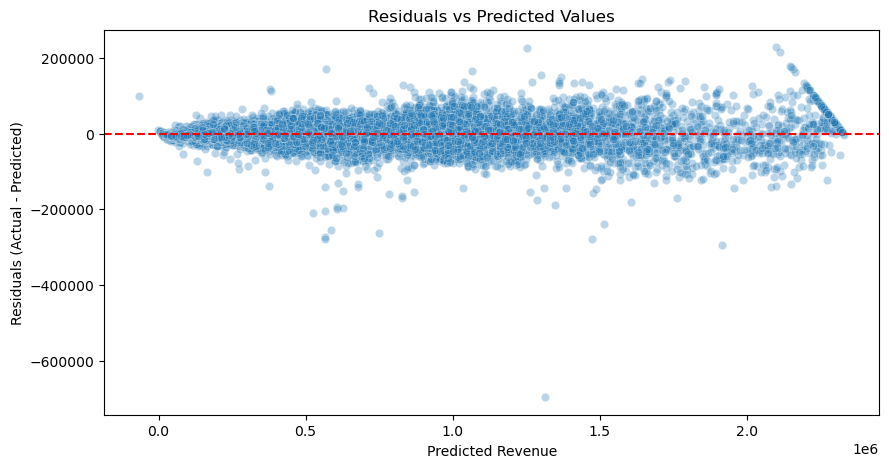

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from your best model (Gradient Boosting)
best_model = reg_models["Gradient Boosting"]
y_pred = best_model.predict(X_test_reg)
residuals = y_test_reg - y_pred

# Plot Residuals
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Revenue')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()

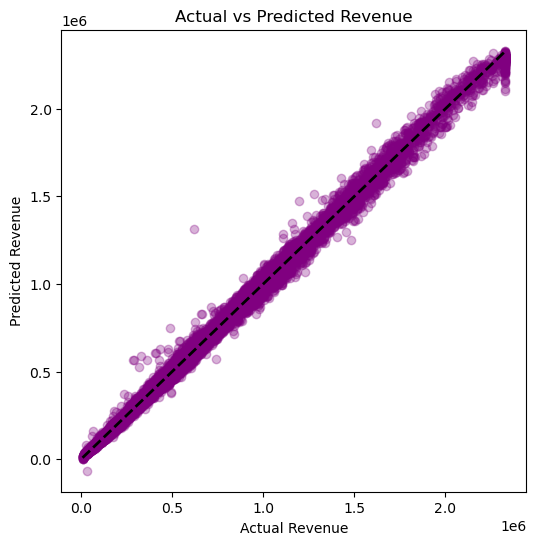

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.3, color='purple')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd

# Initialize the classification models (scaling linear models to prevent convergence/conditioning issues)
clf_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "Ridge Classifier": make_pipeline(StandardScaler(), RidgeClassifier(random_state=42)),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# List to store performance metrics
clf_results = []

print("Training classification models...")
for name, model in clf_models.items():
    # Fit the model
    model.fit(X_train_clf, y_train_clf)
    
    # Predict on test data
    y_pred = model.predict(X_test_clf)
    
    # Calculate evaluation metrics (assuming binary classification; adjust average if multiclass)
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test_clf, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test_clf, y_pred, average='binary', zero_division=0)
    
    # Save results
    clf_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    print(f"✓ {name} trained successfully.")

# Display results as a clean DataFrame
df_clf_results = pd.DataFrame(clf_results).sort_values(by="F1-Score", ascending=False)
print("\n--- Classification Model Comparison Matrix ---")
display(df_clf_results)

Training classification models...
✓ Logistic Regression trained successfully.
✓ Ridge Classifier trained successfully.
✓ Random Forest trained successfully.
✓ Gradient Boosting trained successfully.

--- Classification Model Comparison Matrix ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.996721,0.997067,0.998614,0.997840
3,Gradient Boosting,0.996049,0.997395,0.997395,0.997395
2,Random Forest,0.977765,0.982478,0.988305,0.985383
1,Ridge Classifier,0.897987,0.887219,0.991520,0.936474


In [10]:
import joblib

# 1. Save your best Regression Model
# Since your 'reg_models' dictionary contains the trained models, we grab the Gradient Boosting one
best_reg_model = reg_models["Gradient Boosting"]
joblib.dump(best_reg_model, "Gradient Boosting.pkl")
print("✓ Regression model saved as 'best_revenue_regression_model.pkl'")

# 2. Save your best Classification Model
# We grab the Logistic Regression pipeline from your 'clf_models' dictionary
best_clf_model = clf_models["Logistic Regression"]
joblib.dump(best_clf_model, "Logistic Regression.pkl")
print("✓ Classification model saved as 'best_profit_classification_model.pkl'")

✓ Regression model saved as 'best_revenue_regression_model.pkl'
✓ Classification model saved as 'best_profit_classification_model.pkl'
